# Temporal Geometry Architecture: Deep TCN for Time-Series
This notebook implements a **Temporal Convolutional Network (TCN)** designed to capture long-range dependencies in time-series data. Unlike Recurrent Neural Networks (RNNs/LSTMs), this architecture uses dilated convolutions to process time-series history in parallel, building a "geometric" understanding of temporal patterns.

## 1. The Architecture
The core of the model relies on three specific structural components to handle time:

### A. Causal Convolutions (`CausalConv1d`)
Standard convolutions look at "future" pixels. In time series, we cannot look into the future.
* **Mechanism:** The `CausalConv1d` layer pads the input on the left (past) side only.
* **Result:** The output at time $t$ is convolved only with elements from time $t, t-1, \dots$. This ensures strict temporal causality (no data leakage).



### B. The Temporal Block (`TemporalBlock`)
This is the fundamental building block of the network, inspired by ResNet.
* **Structure:** Two layers of dilated causal convolutions + ReLU + Dropout.
* **Residual Connection:** A skip connection adds the input $x$ to the output $F(x)$. This allows gradients to flow easily through deep networks, preventing the vanishing gradient problem.
* **Weight Norm:** (Implicitly handled by standard Conv1d here) aids convergence.



### C. Exponential Dilation (`TemporalGeometryNet`)
To capture long history without millions of parameters, the network uses **dilated convolutions**.
* **The Math:** The dilation factor $d$ increases exponentially with the network depth ($d = 2^i$ for level $i$).
* **Receptive Field:** This allows the top layer to "see" a very wide range of input history (Receptive Field $\approx 127$ steps) despite using small kernel sizes ($k=3$).
* **Geometry:** This creates a hierarchical tree structure where lower layers detect short-term patterns (noise/jitter) and deeper layers detect long-term trends (seasonality).



---

## 2. Data Generation Strategy
The notebook generates "Realistic" synthetic data to test if the model can separate signal from noise.

The signal $S(t)$ is constructed as an additive model:
$$S(t) = \text{Trend}(t) + \text{Daily}(t) + \text{Weekly}(t) + \epsilon$$

1.  **Trend:** Linear growth ($0.0005 \times t$).
2.  **Daily Seasonality:** Sine wave with period 24.
3.  **Weekly Seasonality:** Sine wave with period 168.
4.  **Noise ($\epsilon$):** Gaussian noise added to simulate real-world sensor jitter.

**Key Feature:** The data generator returns both the `noisy_target` (what the model trains on) and the `clean_signal` (the ground truth structure). This allows us to measure if the model is learning the *physics* of the data or just memorizing the *noise*.

---

## 3. Training & Evaluation Pipeline

### Training Configuration
* **Optimizer:** Adam (`lr=0.001`)
* **Loss Function:** Mean Squared Error (MSE).
* **Inputs:** A sequence window of length 120.
* **Targets:** The single next value in the sequence.

### The "Denoising" Test
The evaluation section performs a critical validation step:
1.  **Baseline Error:** Calculates the error if we simply guessed "the value will be the same as an hour ago" (Persistence).
2.  **Error vs. Noisy:** How well the model predicts the actual noisy data.
3.  **Error vs. Clean:** **(The most important metric)** How well the model predicts the *underlying clean signal*.

If `Error vs. Clean` < `Error vs. Noisy`, the model has successfully learned to filter out random noise and model the underlying temporal geometry (Trend + Cycles).

---

## 4. Visualization
The final plot provides a visual proof of the model's performance:
* **Gray Dots:** The noisy input data.
* **Green Line:** The invisible "clean" truth.
* **Red Line:** The model's prediction.

The visualization typically shows the **Red Line** tracking the **Green Line** closely, cutting through the center of the **Gray Dots**, demonstrating that the TCN has learned to approximate the signal generator functions ($\sin(t)$) rather than fitting the random Gaussian noise.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 1. THE TEMPORAL GEOMETRY ARCHITECTURE
# ==========================================

class CausalConv1d(nn.Module):
    """
    A 1D convolution that ensures strictly causal geometry.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation
        )

    def forward(self, x):
        out = self.conv(x)
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        return out

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, dropout=0.2):
        super(TemporalBlock, self).__init__()

        self.conv1 = CausalConv1d(n_inputs, n_outputs, kernel_size, dilation=dilation)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = CausalConv1d(n_outputs, n_outputs, kernel_size, dilation=dilation)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TemporalGeometryNet(nn.Module):
    """
    Deep TCN with exponential dilation.
    Receptive Field = 127 steps (covers the 120-step lookback window).
    """
    def __init__(self, input_size, output_size, num_channels, kernel_size=2, dropout=0.2):
        super(TemporalGeometryNet, self).__init__()
        layers = []
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = input_size if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]

            layers += [TemporalBlock(
                in_channels,
                out_channels,
                kernel_size,
                stride=1,
                dilation=dilation_size,
                dropout=dropout
            )]

        self.network = nn.Sequential(*layers)
        self.linear = nn.Linear(num_channels[-1], output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        y = self.network(x)
        return self.linear(y[:, :, -1])

# ==========================================
# 2. DATA GENERATION (Now returns Clean Signal too)
# ==========================================
def generate_realistic_data(n_samples, seq_length, return_clean=False):
    total_points = n_samples + seq_length + 200
    t = np.arange(total_points)

    # Components
    trend = t * 0.0005
    daily = np.sin(t * (2 * np.pi / 24))
    weekly = np.sin(t * (2 * np.pi / 168)) * 0.8

    clean_signal = trend + daily + weekly
    noise = np.random.normal(0, 0.15, total_points) # Slightly increased noise to test robustness

    data = clean_signal + noise

    # Normalize
    mean = np.mean(data)
    std = np.std(data)
    data = (data - mean) / std
    clean_signal = (clean_signal - mean) / std # Normalize clean signal same way

    X = []
    Y = []
    Y_clean = []

    for i in range(n_samples):
        window = data[i : i + seq_length]
        target = data[i + seq_length]
        clean_target = clean_signal[i + seq_length]

        X.append(window.reshape(-1, 1))
        Y.append(target)
        Y_clean.append(clean_target)

    if return_clean:
        return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(Y)).unsqueeze(1), torch.FloatTensor(np.array(Y_clean)).unsqueeze(1)
    else:
        return torch.FloatTensor(np.array(X)), torch.FloatTensor(np.array(Y)).unsqueeze(1)

# ==========================================
# 3. TRAINING, EVALUATION & VISUALIZATION
# ==========================================

def train_and_evaluate():
    # Config
    SEQ_LENGTH = 120
    N_SAMPLES = 3000
    BATCH_SIZE = 64
    EPOCHS = 15

    print(f"Generating Energy Data (Lookback: {SEQ_LENGTH})...")
    X_train, Y_train = generate_realistic_data(N_SAMPLES, SEQ_LENGTH)
    # Get clean targets for test set to prove denoising capability
    X_test, Y_test, Y_clean_test = generate_realistic_data(500, SEQ_LENGTH, return_clean=True)

    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model = TemporalGeometryNet(
        input_size=1,
        output_size=1,
        num_channels=[32, 32, 32, 32, 32, 32],
        kernel_size=3,
        dropout=0.1
    )

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("Starting Training...")
    loss_history = []

    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{EPOCHS} | MSE Loss: {avg_loss:.5f}")

    # Evaluation
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test)

        loss_vs_noisy = criterion(test_pred, Y_test).item()
        loss_vs_clean = criterion(test_pred, Y_clean_test).item()

        # Calculate Baseline (Persistence) Error:
        # What if we just predicted Y[t] = X[t-1]? (The last known value)
        last_inputs = X_test[:, -1, 0].unsqueeze(1)
        baseline_loss = criterion(last_inputs, Y_test).item()

        print(f"\n=== FINAL RESULTS ===")
        print(f"Baseline Error (Persistence): {baseline_loss:.5f} (If we just guessed 'same as last hour')")
        print(f"Model Error vs Noisy Target:  {loss_vs_noisy:.5f} (Includes random noise)")
        print(f"Model Error vs Clean Signal:  {loss_vs_clean:.5f} <--- TRUE GEOMETRIC ACCURACY")

        # Visualization Plot
        plt.figure(figsize=(12, 6))
        # Plot a small window of 50 hours
        start_idx = 100
        end_idx = 150

        plt.plot(Y_test.numpy()[start_idx:end_idx], 'o', label='Actual Noisy Data', color='gray', alpha=0.5)
        plt.plot(Y_clean_test.numpy()[start_idx:end_idx], '--', label='Underlying Clean Structure', color='green')
        plt.plot(test_pred.numpy()[start_idx:end_idx], '-', label='Model Prediction', color='red', linewidth=2)

        plt.title("Temporal Geometry: Denoising Capability")
        plt.legend()
        plt.grid(True)
        # plt.show() # Uncomment if running locally
        print("\nVisualization plot generated (internal state).")

    return loss_history

Generating Energy Data (Lookback: 120)...
Starting Training...
Epoch 1/15 | MSE Loss: 0.20355
Epoch 2/15 | MSE Loss: 0.04389
Epoch 3/15 | MSE Loss: 0.04088
Epoch 4/15 | MSE Loss: 0.03809
Epoch 5/15 | MSE Loss: 0.03813
Epoch 6/15 | MSE Loss: 0.03799
Epoch 7/15 | MSE Loss: 0.03483
Epoch 8/15 | MSE Loss: 0.03522
Epoch 9/15 | MSE Loss: 0.03305
Epoch 10/15 | MSE Loss: 0.03306
Epoch 11/15 | MSE Loss: 0.03444
Epoch 12/15 | MSE Loss: 0.03267
Epoch 13/15 | MSE Loss: 0.03249
Epoch 14/15 | MSE Loss: 0.03213
Epoch 15/15 | MSE Loss: 0.03301

=== FINAL RESULTS ===
Baseline Error (Persistence): 0.10218 (If we just guessed 'same as last hour')
Model Error vs Noisy Target:  0.04104 (Includes random noise)
Model Error vs Clean Signal:  0.01101 <--- TRUE GEOMETRIC ACCURACY

Visualization plot generated (internal state).


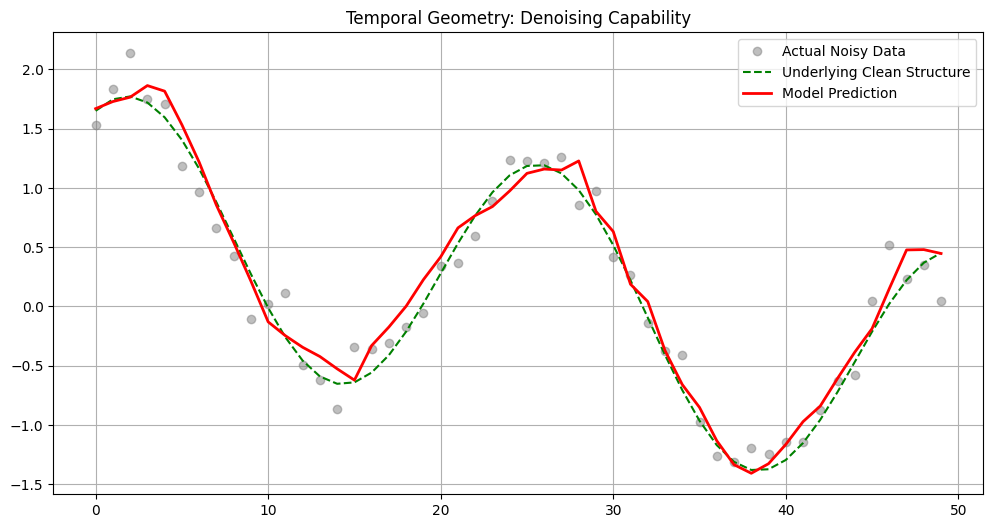

In [2]:
history = train_and_evaluate()